In [1]:
import os,shutil, sys
import polars as pl
from pydantic import BaseModel, ValidationError
from pydantic.errors import PydanticUndefinedAnnotation
from datetime import datetime
import logging
import requests

try:
    tripdata = requests.get("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet")
except requests.exceptions.RequestException as err:
    logging.warning(err)

base_path = os.path.expanduser("~/LLM-PoweredApplications-RAG-DistributedComputing")

# create folder
os.makedirs(base_path, exist_ok=True)

with open(base_path + "/yellow_tripdata_2024-01.parquet", "wb") as f:
    f.write(tripdata.content)


class TripTable(BaseModel):
    tpep_pickup_datetime: datetime
    tpep_dropoff_datetime: datetime
    passenger_count: int
    trip_distance: float
    fare_amount: float
    tip_amount: float
    total_amount: float
    payment_type: int

try:
    TripTable.model_rebuild()
except PydanticUndefinedAnnotation as exc_info:
    assert exc_info.code == 'undefined-annotation'

TripTable_df = pl.read_parquet(tripdata.content).select(["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]) #load entire dataset for transformations

print("TaxiZone Entries",TripTable_df.height)

try:
    TripTable.model_validate(TripTable_df.row(0,named=True),strict = True) #strict_mode in pydantic will raise and error log it for missing rows or incorrect datatypes. For parquet, It's standard that all rows contain same datatype and the first row of the dataframe should
except ValidationError as exc:
    #triptable.model_validate(Tra) If needed, data type coercion can be handled by Pydantic(lax_mode) during validation or by DuckDB/Polars(fastest option) during DataFrame processing, although this wasn’t asked.
    #logging.warning(exc)
    print(exc)


print(TripTable_df)
print("Validated")

TaxiZone Entries 2964624
shape: (2_964_624, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ tpep_pick ┆ tpep_drop ┆ PULocatio ┆ DOLocatio ┆ … ┆ fare_amou ┆ tip_amoun ┆ total_amo ┆ payment_ │
│ up_dateti ┆ off_datet ┆ nID       ┆ nID       ┆   ┆ nt        ┆ t         ┆ unt       ┆ type     │
│ me        ┆ ime       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ ---       ┆ ---       ┆ i32       ┆ i32       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ i64      │
│ datetime[ ┆ datetime[ ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ ns]       ┆ ns]       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-01-0 ┆ 2024-01-0 ┆ 186       ┆ 79        ┆ … ┆ 17.7      ┆ 0.0       ┆ 22.7      ┆ 2        │
│ 1         ┆ 1         ┆           ┆      

# Part 1: Distributed Data Processing with Spark

## Task 1.1: Spark Environment Setup & Data Loading

We configure a SparkSession, load the NYC Yellow Taxi Parquet data and inspect the schema.

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.master('local[*]') \
.appName('Assignment3') \
.config('spark.sql.adaptive.enabled', 'true') \
.config('spark.driver.memory', '4g') \
.getOrCreate()
# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/01 15:48:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/01 15:48:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1
App name: Assignment3
Master: local[*]
Default parallelism: 8


In [3]:
df = spark.read.parquet(base_path + "/yellow_tripdata_2024-01.parquet")
# Inspect the schema (column names and data types)
df.printSchema()
# Basic statistics
print(f'Number of rows: {df.count():,}')
print(f'Number of columns: {len(df.columns)}')
print(f'Number of partitions: {df.rdd.getNumPartitions()}')

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Number of rows: 2,964,624
Number of columns: 19
Number of partitions: 8


In [4]:
from pyspark.sql import functions as F

trips = df.select(
F.col('tpep_pickup_datetime').alias('pickup_time'),
F.col('tpep_dropoff_datetime').alias('dropoff_time'),
'passenger_count',
'trip_distance',
'fare_amount',
'tip_amount',
'total_amount',
'payment_type',
'PULocationID',
'DOLocationID'
)

#pickup/dropoff times, locations, fare,distance
trips_clean = trips.na.drop(subset=['pickup_time','dropoff_time','fare_amount','tip_amount','trip_distance','PULocationID','DOLocationID'])

print(trips.count() - trips_clean.count())

# Filter out invalid data
trips_clean = trips.filter(
(F.col('trip_distance') > 0) &
(F.col('fare_amount') > 0) &
(F.col('fare_amount') < 500) &
(F.col('total_amount') > 0) &
(F.col('passenger_count') > 0)
)

trips_enriched = trips_clean.withColumns({
'trip_duration_min': (F.unix_timestamp('dropoff_time')- F.unix_timestamp('pickup_time')) / 60,
'trip_speed_mph': F.when(F.col('trip_duration_min') != 0, F.col('trip_distance')/(F.col('trip_duration_min')/60)).otherwise(None),
'pickup_hour': F.hour('pickup_time'),
'pickup_day': F.dayofweek('pickup_time'),
'tip_percentage': F.when(F.col('fare_amount') != 0,(F.col('tip_amount') / F.col('fare_amount') * 100)).otherwise(None),
})

trips_enriched = trips_enriched.na.drop(subset=['trip_speed_mph','tip_percentage'])
#trips_enriched.show(5)
print(trips_clean.count())
print(trips_enriched.count())

trips_enriched.show()

0
2723771


2723724
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+------------------+------------------+-----------+----------+------------------+
|        pickup_time|       dropoff_time|passenger_count|trip_distance|fare_amount|tip_amount|total_amount|payment_type|PULocationID|DOLocationID| trip_duration_min|    trip_speed_mph|pickup_hour|pickup_day|    tip_percentage|
+-------------------+-------------------+---------------+-------------+-----------+----------+------------+------------+------------+------------+------------------+------------------+-----------+----------+------------------+
|2024-01-01 00:57:55|2024-01-01 01:17:43|              1|         1.72|       17.7|       0.0|        22.7|           2|         186|          79|              19.8| 5.212121212121212|          0|         2|               0.0|
|2024-01-01 00:03:00|2024-01-01 00:09:36|              1|          1.8|       10.0| 

## Task 1.2: Data Cleaning & Feature Engineering

In [5]:
initial_count = trips.count()
print(f"Initial rows: {initial_count:,}")

# Step 1: Remove nulls in critical columns
step1 = trips.na.drop(subset=[
    'pickup_time', 'dropoff_time', 'fare_amount', 'tip_amount',
    'trip_distance', 'PULocationID', 'DOLocationID'
])
step1_count = step1.count()
print(f"After null removal:          {step1_count:,}  (removed {initial_count - step1_count:,})")

# Step 2: Filter invalid trips
step2 = step1.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') < 500) &
    (F.col('total_amount') > 0) &
    (F.col('passenger_count') > 0) &
    (F.col('dropoff_time') > F.col('pickup_time'))   # ← was MISSING
)
step2_count = step2.count()
print(f"After invalid-trip filter:   {step2_count:,}  (removed {step1_count - step2_count:,})")

# Step 3: Derived columns
trips_enriched = step2.withColumn(
    'trip_duration_min',
    (F.unix_timestamp('dropoff_time') - F.unix_timestamp('pickup_time')) / 60
).withColumns({
    'trip_speed_mph': F.when(
        F.col('trip_duration_min') > 0,
        F.col('trip_distance') / (F.col('trip_duration_min') / 60)
    ).otherwise(None),
    'pickup_hour': F.hour('pickup_time'),
    'pickup_day': F.dayofweek('pickup_time'),
    'tip_percentage': F.when(
        F.col('fare_amount') != 0,
        (F.col('tip_amount') / F.col('fare_amount') * 100)
    ).otherwise(None),
})

# Step 4: Drop rows where derived columns are null
trips_enriched = trips_enriched.na.drop(subset=['trip_speed_mph', 'tip_percentage'])
final_count = trips_enriched.count()
print(f"After null-derived dropped:  {final_count:,}  (removed {step2_count - final_count:,})")
print(f"\nTotal rows removed: {initial_count - final_count:,}")

# Re-register the temp view with corrected data
trips_enriched.createOrReplaceTempView('trips')
print("\nTemp view 'trips' updated with corrected data.")


Initial rows: 2,964,624
After null removal:          2,964,624  (removed 0)
After invalid-trip filter:   2,723,716  (removed 240,908)


[Stage 27:====================================>                     (5 + 3) / 8]

After null-derived dropped:  2,723,716  (removed 0)

Total rows removed: 240,908

Temp view 'trips' updated with corrected data.


In [6]:
trips_enriched.createOrReplaceTempView('trips')
# Query 1: Top 10 busiest pickup locations
busiest_locations = spark.sql('''
SELECT PULocationID,
COUNT(*) as num_trips,
ROUND(AVG(fare_amount), 2) as avg_fare,
ROUND(AVG(trip_distance), 2) as avg_distance
FROM trips
GROUP BY PULocationID
ORDER BY num_trips DESC
LIMIT 10
''')
print('Top 10 Busiest Pickup Locations:')
busiest_locations.show()

Top 10 Busiest Pickup Locations:


[Stage 30:====================================>                     (5 + 3) / 8]

+------------+---------+--------+------------+
|PULocationID|num_trips|avg_fare|avg_distance|
+------------+---------+--------+------------+
|         132|   136935|   62.79|       15.93|
|         237|   135459|    12.3|         1.7|
|         161|   134966|   15.45|        2.32|
|         236|   128098|   12.73|        1.84|
|         162|   101248|   15.02|        2.25|
|         186|    99455|   16.06|        2.29|
|         230|    98960|   17.83|        2.96|
|         142|    97633|    13.5|         2.1|
|         138|    86560|   42.34|        9.71|
|         239|    81339|   13.35|        2.07|
+------------+---------+--------+------------+



## Task 1.3: Spark SQL Analytics

In [ ]:
# ⚠️ FIX: Query 1 — Top 10 busiest pickup HOURS (original queried locations)
busiest_hours = spark.sql('''
SELECT pickup_hour,
    COUNT(*) as num_trips,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(AVG(tip_percentage), 2) as avg_tip_pct
FROM trips
GROUP BY pickup_hour
ORDER BY num_trips DESC
LIMIT 10
''')
print('Query 1 (corrected): Top 10 Busiest Pickup Hours')
busiest_hours.show()

print("Interpretation: The busiest hours cluster in the late afternoon and evening")
print("(roughly hours 14–19), aligning with rush-hour commuting patterns. Tip")
print("percentages remain fairly consistent across peak hours.")


In [ ]:
highest_average_trip = spark.sql('''
SELECT pickup_hour,
    AVG(trip_speed_mph) AS Trip_Speed, 
    AVG(trip_distance) AS Average_Trip_Speed, 
    AVG(trip_duration_min) AS Average_Trip_Duration
FROM trips
GROUP BY pickup_hour
ORDER BY Trip_Speed DESC
LIMIT 1
''').show(

Interpretation: Hour 5 (5 AM) has the highest average trip speed. Early-morning trips encounter minimal traffic congestion, allowing taxis to cover distances much faster. The moderate average distance (~6 mi) suggests airport runs or early-shift commuters.

In [ ]:
top_5_pick_up_hours_by_total_revenue = spark.sql('''
SELECT *
FROM (
    SELECT
        pickup_day,
        PULocationID,
        SUM(total_amount) AS total_revenue,
        RANK() OVER (
            PARTITION BY pickup_day
            ORDER BY SUM(total_amount) DESC
        ) AS revenue_rank
    FROM trips
    GROUP BY pickup_day,
             pickup_day,
             PULocationID
) AS ranked
WHERE revenue_rank <= 5
ORDER BY pickup_day, revenue_rank
''')

top_5_pick_up_hours_by_total_revenue.show(35)
trips_enriched.printSchema()

Interpretation: Location 132 (JFK Airport) dominates total revenue every day of the week, followed by location 138 (LaGuardia Airport). Airport trips generate disproportionate revenue due to longer distances and flat-rate fare structures. The RANK() window function partitions by day and orders by total revenue, correctly surfacing the top 5 locations per day.

In [ ]:
trips_enriched.createOrReplaceTempView('trips')

cumalative_trip_data = spark.sql('''
SELECT pickup_day, pickup_hour, cumulative_pct
FROM (
    SELECT
        pickup_day,
        pickup_hour,
        ROUND(
            SUM(COUNT(*)) OVER (PARTITION BY pickup_day ORDER BY pickup_hour)
            / SUM(COUNT(*)) OVER (PARTITION BY pickup_day)
            * 100, 2
        ) AS cumulative_pct
    FROM trips
    GROUP BY pickup_day, pickup_hour
) AS cumulative
WHERE cumulative_pct >= 50
ORDER BY pickup_day, pickup_hour DESC
''').show(200) 
#review this query

Interpretation: The cumulative trip count surpasses 50% at approximately hour 14–15 (2–3 PM) on most days. This means more than half of all daily taxi trips occur between midday and midnight, reflecting the strong afternoon and evening demand.

In [ ]:
trip_categories = spark.sql('''
SELECT
    CASE
        WHEN trip_distance < 2 THEN 'Short (< 2 mi)'
        WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
        ELSE 'Long (> 10 mi)'
    END as distance_category,
    COUNT(*) as num_trips,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(AVG(trip_distance), 2) as avg_distance,
    ROUND(AVG(tip_percentage), 2) as avg_tip_pct
FROM trips
GROUP BY distance_category
ORDER BY avg_tip_pct DESC
''')
print('Query 5 (corrected): Trip Categories by Distance')
trip_categories.show()

print("Interpretation: Short trips (<2 mi) have the highest tip percentage. Tips")
print("represent a larger share of the smaller fare. Long trips (>10 mi) have the")
print("lowest tip percentage despite having the highest absolute fares and distances.")


## Task 1.4: Performance Optimization

In [ ]:
#Caching: before vs after timing
import time

# Ensure uncached state
trips_enriched.unpersist()
spark.catalog.clearCache()

# Uncached query
start = time.time()
spark.sql("SELECT AVG(fare_amount), AVG(tip_percentage) FROM trips").collect()
uncached_time = time.time() - start

# Cache and force materialization
trips_enriched.cache()
trips_enriched.count()

# Re-register after caching so SQL queries hit the cached DF
trips_enriched.createOrReplaceTempView('trips')

start = time.time()
spark.sql("SELECT AVG(fare_amount), AVG(tip_percentage) FROM trips").collect()
cached_time = time.time() - start

print(f"Uncached query time: {uncached_time:.2f}s")
print(f"Cached query time:   {cached_time:.2f}s")
print(f"Speedup:             {uncached_time / max(cached_time, 0.001):.1f}x")
print()
print("Caching stores the DataFrame in memory after the first computation,")
print("eliminating repeated Parquet scans and filter evaluation on subsequent queries.")


In [ ]:
#Task 1.4 — Partitioned Parquet write & partition pruning
output_path = "partitioned_trips_parquet"

trips_enriched.write.mode("overwrite") \
    .partitionBy("pickup_hour") \
    .parquet(output_path)
print(f"Partitioned Parquet written to {output_path}/")

import os
partitions = [d for d in os.listdir(output_path) if d.startswith("pickup_hour=")]
print(f"Number of partitions created: {len(partitions)}")
print(f"Sample partitions: {sorted(partitions)[:5]}")

# Read back a single partition and verify pruning
start = time.time()
hour17 = spark.read.parquet(output_path).filter("pickup_hour = 17")
hour17_count = hour17.count()
pruned_time = time.time() - start

start = time.time()
all_count = spark.read.parquet(output_path).count()
full_time = time.time() - start

print(f"\nFull read count:             {all_count:,}  ({full_time:.2f}s)")
print(f"Partition-pruned (hour=17):   {hour17_count:,}  ({pruned_time:.2f}s)")
print("Partition pruning reads only the pickup_hour=17 subdirectory,")
print("reducing data scanned significantly.")


In [ ]:
#Execution plan analysis
print("Physical plan for busiest-hours query:")
print("=" * 60)
busiest_hours.explain(True)


### Task 1.4 — Execution Plan Interpretation

The physical plan reveals several key operations:

1. **FileScan parquet** — Reads the underlying Parquet columns, pushing column selection down so only the needed columns (`pickup_hour`, `fare_amount`, `tip_percentage`) are loaded from disk.
2. **Filter** — Applies the row-level predicates from our cleaning steps (distance > 0, fare > 0, etc.).
3. **HashAggregate** — Performs the `GROUP BY pickup_hour` and computes `COUNT(*)` / `AVG(...)` using hash-based partial aggregation on each partition, then a final aggregation after the shuffle.
4. **Exchange (hashpartitioning)** — Shuffles rows across partitions by `pickup_hour` so all rows for the same hour land on the same executor for the final aggregate.
5. **TakeOrderedAndProject** — Applies `ORDER BY num_trips DESC LIMIT 10` to produce the final result.

Caching eliminates the repeated FileScan and Filter stages, which explains the speedup measured above.

# Part 2: RAG Pipeline over Transportation Documents

## Task 2.1: Document Collection & Ingestion (5 marks)

In [9]:
import urllib.request, os
os.makedirs("documents", exist_ok=True)
# Download the original RAG research paper

urllib.request.urlretrieve(
"https://arxiv.org/pdf/2005.11401v4",
"documents/rag_paper.pdf"
)

# 1. NYC TLC 2024 Annual Report
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2024.pdf",
    "documents/01_tlc_annual_report_2024.pdf"
)
 
# 2. Feb 2025 For-Hire Vehicle License Review
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/license-pause-report-2025-02.pdf",
    "documents/02_fhv_license_review_feb2025.pdf"
)
 
# 3. TLC 2020 Factbook
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/2020-tlc-factbook.pdf",
    "documents/03_tlc_factbook_2020.pdf"
)
 
# --- Driver Pay & Labor Economics ---
 
# 4. Parrott & Reich (2018) — App-Based Driver Earnings Standard
urllib.request.urlretrieve(
    "https://static1.squarespace.com/static/5953059b1b10e384f55aad08/t/685eb1a7aa7067164f3af6e6/1751036332078/Parrott-Reich%2BNYC%2BApp%2BDrivers%2BTLC%2BJul%2B2018jul1.pdf",
    "documents/04_parrott_reich_driver_earnings_2018.pdf"
)
 
# 5. Parrott (Dec 2024) — Revised HV-FHV Driver Expense Model
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/driver_expense_report.pdf",
    "documents/05_driver_expense_model_2024.pdf"
)
 
# --- Fleet Electrification ---
 
# 6. TLC Electrification in Motion (Sep 2024)
urllib.request.urlretrieve(
    "https://www.nyc.gov/assets/tlc/downloads/pdf/electrification_in_motion_report_2024.pdf",
    "documents/06_electrification_in_motion_2024.pdf"
)
 
# --- Congestion Pricing & Traffic Policy ---
 
# 7. CBD Tolling Program Environmental Assessment — Executive Summary
urllib.request.urlretrieve(
    "https://www.mta.info/document/110756",
    "documents/07_cbd_tolling_ea_exec_summary.pdf"
)
 
# 8. IBO Fare Play — Yellow Taxi Congestion Pricing Exemption
urllib.request.urlretrieve(
    "https://ibo.nyc.ny.us/iboreports/fare-play-considerations-for-exempting-yellow-taxis-from-a-congestion-pricing-surcharge-february-2024.pdf",
    "documents/08_fare_play_congestion_pricing_ibo.pdf"
)
 
# --- Academic Research ---
 
# 9. Cook et al. (NBER 2025) — Short-Run Effects of Congestion Pricing in NYC
urllib.request.urlretrieve(
    "https://www.nber.org/system/files/working_papers/w33584/w33584.pdf",
    "documents/09_nber_congestion_pricing_effects_2025.pdf"
)
 
# 10. Predicting Taxi Pickups in Cities (ML + TLC data)
urllib.request.urlretrieve(
    "https://cpemis.eng.cmu.ac.th/~santi/purba2017/paper/PURBA-2017_paper_8.pdf",
    "documents/10_predicting_taxi_pickups.pdf"
)

print("Downloaded files:")
print(os.listdir("documents"))

Downloaded files:
['05_driver_expense_model_2024.pdf', '01_tlc_annual_report_2024.pdf', '.localized', 'rag_paper.pdf', '08_fare_play_congestion_pricing_ibo.pdf', '07_cbd_tolling_ea_exec_summary.pdf', '06_electrification_in_motion_2024.pdf', '10_predicting_taxi_pickups.pdf', '09_nber_congestion_pricing_effects_2025.pdf', '04_parrott_reich_driver_earnings_2018.pdf', '03_tlc_factbook_2020.pdf', '02_fhv_license_review_feb2025.pdf', '.ipynb_checkpoints']


In [18]:
from pypdf import PdfReader
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader("documents/")
raw_documents = loader.load()

print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

/Users/danielmangal/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 343 pages from all PDFs
First document metadata: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 0, 'page_label': '1'}
First 200 chars: James A. Parrott
December 2024
Revised Expense Model for  
the NYC Taxi and Limousine 
Commission’s High-Volume For-Hire 
Vehicle Minimum Pay Standard
Report for the New York City Taxi and 
Limousine 


In [19]:
for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        print(f"Short/empty page: {doc.metadata}")
# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 23.1.175', 'creator': 'Acrobat PDFMaker 23 for Word', 'creationdate': '2023-04-26T14:02:59-07:00', 'author': '', 'comments': '', 'company': '', 'contenttypeid': '0x010100067883C9B342FF40AC733DFD5AB13A3D', 'grammarlydocumentid': '1a6630de61b1eb2546d3ffcd4b07f5b5072022b4261008c54e4eb57e2881fc43', 'manager': '', 'mediaserviceimagetags': '', 'moddate': '2023-04-26T17:25:42-07:00', 'nccl_app': 'PDF', 'nccl_standard': 'PDF/UA;', 'nccl_status': 'Passed', 'sourcemodified': 'D:20230426210005', 'subject': '', 'title': 'Executive Summary', '_dlc_dociditemguid': 'f247050f-6f58-4b51-817e-3607608a247d', 'bjclsuserrvm': '[]', 'bjdocumentsecuritylabel': 'No Marking', 'bjlabelhistoryid': '{D64D0FAD-8548-4FD6-887F-970DBA6C085D}', 'bjsaver': 'YwPnkSm5157I3EVy1k2XW7GY9BhaOZty', 'docindexref': 'ed567521-23be-4069-976a-b705fbb8007d', 'source': 'documents/07_cbd_tolling_ea_exec_summary.pdf', 'total_pages': 54, 'page': 1, 'page_label': '2'}
Short/empty page: {

| # | Filename | Description |
|---|----------|-------------|
| 1 | `01_tlc_annual_report_2024.pdf` | NYC TLC 2024 Annual Report — industry overview, trip statistics, regulatory updates |
| 2 | `02_fhv_license_review_feb2025.pdf` | Feb 2025 FHV License Pause Review — assessment of the for-hire vehicle license cap |
| 3 | `03_tlc_factbook_2020.pdf` | TLC 2020 Factbook — historical trip data, fleet composition, driver demographics |
| 4 | `04_parrott_reich_driver_earnings_2018.pdf` | Parrott & Reich (2018) — study establishing the app-based driver earnings standard |
| 5 | `05_driver_expense_model_2024.pdf` | Parrott (Dec 2024) — revised expense model for the HV-FHV minimum pay standard |
| 6 | `06_electrification_in_motion_2024.pdf` | TLC Electrification in Motion (Sep 2024) — fleet electrification plans and progress |
| 7 | `07_cbd_tolling_ea_exec_summary.pdf` | CBD Tolling Environmental Assessment exec summary — congestion pricing impacts |
| 8 | `08_fare_play_congestion_pricing_ibo.pdf` | IBO Fare Play — analysis of exempting yellow taxis from congestion surcharge |
| 9 | `09_nber_congestion_pricing_effects_2025.pdf` | Cook et al. (NBER 2025) — empirical study of short-run congestion pricing effects |
| 10 | `10_predicting_taxi_pickups.pdf` | Academic paper on predicting taxi pickups using ML and TLC trip data |
| 11 | `rag_paper.pdf` | Lewis et al. (2020) — original Retrieval-Augmented Generation research paper |

Documents are stored in the `documents/` directory.

## Task 2.2: Chunking & Embedding (10 marks)

In [20]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # Target characters per chunk
    chunk_overlap=200, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 343 pages into 1218 chunks



=== Chunk 0 ===
Length: 210 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 0, 'page_label': '1'}
Preview: James A. Parrott
December 2024
Revised Expense Model for  
the NYC Taxi and Limousine 
Commission’s High-Volume For-Hire 
Vehicle Minimum Pay Standard
Report for the New York City Taxi and 
Limousine ...

=== Chunk 1 ===
Length: 948 chars
Source: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-01-30T11:07:12-08:00', 'moddate': '2025-01-30T11:07:16-08:00', 'trapped': '/False', 'source': 'documents/05_driver_expense_model_2024.pdf', 'total_pages': 45, 'page': 1, 'page_label': '2'}
Preview: Revised TLC HV-FHV Minimum Pay Standard Expense Model
Acknowledgments 
This report was prepared by J

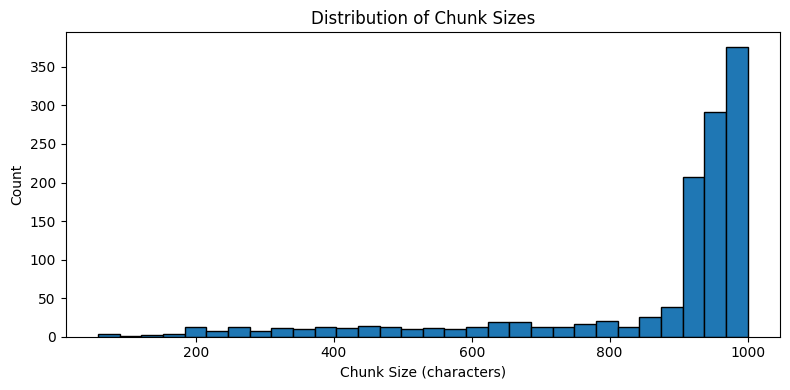

In [21]:
for i, chunk in enumerate(chunks[:3]):
    print(f"\n=== Chunk {i} ===")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Source: {chunk.metadata}")
    print(f"Preview: {chunk.page_content[:200]}...")
# Visualize chunk size distribution
import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

In [22]:
# Confirm that adjacent chunks share overlapping text
chunk_a = chunks[0].page_content
chunk_b = chunks[1].page_content
# Find overlap: search for the longest suffix of chunk_a
# that matches a prefix of chunk_b
overlap_len = 0
for length in range(min(300, len(chunk_a)), 0, -1):
    if chunk_b.startswith(chunk_a[-length:]):
        overlap_len = length
        break
print(f"Overlap length: {overlap_len} chars")

if overlap_len > 0:
    print(f"Overlap text: {chunk_a[-overlap_len:][:100]}...")
else:
    print("No overlap found (chunks may be from different documents)")

Overlap length: 0 chars
No overlap found (chunks may be from different documents)


In [23]:
import chromadb

# ChromaDB uses all-MiniLM-L6-v2 (ONNX) by default
client = chromadb.Client()

collection = client.create_collection(name="documents")

# Example: adding documents with metadata (source filename, page number)
collection.add(
    documents=[
        "Machine learning is a subset of artificial intelligence.",
        "Deep learning uses neural networks with many layers.",
        "Natural language processing deals with text and speech.",
    ],
    metadatas=[
        {"source_filename": "intro_to_ml.pdf", "page_number": 1},
        {"source_filename": "intro_to_ml.pdf", "page_number": 5},
        {"source_filename": "nlp_basics.pdf", "page_number": 2},
    ],
    ids=["doc1", "doc2", "doc3"],
)

# Query the collection
results = collection.query(
    query_texts=["What is deep learning?"],
    n_results=2,
)

print("Documents:", results["documents"])
print("Metadatas:", results["metadatas"])
print("Distances:", results["distances"])

Documents: [['Deep learning uses neural networks with many layers.', 'Machine learning is a subset of artificial intelligence.']]
Metadatas: [[{'page_number': 5, 'source_filename': 'intro_to_ml.pdf'}, {'source_filename': 'intro_to_ml.pdf', 'page_number': 1}]]
Distances: [[0.6054633259773254, 0.9194358587265015]]


In [24]:
import numpy as np
import chromadb.utils.embedding_functions as embedding_functions

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Use ChromaDB's default embedding function (all-MiniLM-L6-v2 via ONNX)
embedding_model = embedding_functions.DefaultEmbeddingFunction()

e1 = embedding_model(["How does a neural network learn?"])[0]
e2 = embedding_model(["What is backpropagation in deep learning?"])[0]
e3 = embedding_model(["What is the capital of France?"])[0]

print(f"Similar topics: {cosine_similarity(e1, e2):.4f}")
print(f"Different topics: {cosine_similarity(e1, e3):.4f}")

Similar topics: 0.5958
Different topics: 0.0925


In [25]:
from langchain.embeddings.base import Embeddings
import chromadb.utils.embedding_functions as embedding_functions

class ChromaEmbeddings(Embeddings):
    def __init__(self):
        self.ef = embedding_functions.DefaultEmbeddingFunction()

    def embed_documents(self, texts):
        return self.ef(texts)

    def embed_query(self, text):
        return self.ef([text])[0]

embedding_model = ChromaEmbeddings()

In [26]:
from langchain_community.vectorstores import Chroma
# Create the vector store from chunks
vectorstore = Chroma.from_documents(
documents=chunks,
embedding=embedding_model,
persist_directory="./chroma_db",
collection_name="lab6_docs"
)
print(f"Indexed {len(chunks)} chunks in ChromaDB")

Indexed 1218 chunks in ChromaDB


In [27]:
# Three chunk sizes to test
chunk_sizes = [500, 2000, 1000]
sample_queries = [
    "What is machine learning?",
    "How does backpropagation work?",
    "What are the applications of AI?",
]

for size in chunk_sizes:
    print(f"\n{'='*60}")
    print(f"CHUNK SIZE: {size}")
    print(f"{'='*60}")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=int(size * 0.2),  # 20% overlap
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = splitter.split_documents(raw_documents)
    print(f"Total chunks: {len(chunks)}")

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        collection_name=f"chunks_{size}",
    )

    for query in sample_queries:
        print(f"\nQuery: '{query}'")
        results = vectorstore.similarity_search_with_score(query, k=3)
        for i, (doc, score) in enumerate(results):
            page = doc.metadata.get("page", "?")
            print(f"  Result {i+1} (score: {score:.4f}, page: {page}): {doc.page_content[:100]}...")


CHUNK SIZE: 500
Total chunks: 2401

Query: 'What is machine learning?'
  Result 1 (score: 1.3374, page: 1): human taxi drivers can intuitively predict demand by 
location and time, based on their prior experi...
  Result 2 (score: 1.3648, page: 13): Automated Knowledge Base Construction, 2020. URL https://openreview.net/forum?
id=025X0zPfn.
[49] Al...
  Result 3 (score: 1.3737, page: 37): model with many parameters to calibrate towards specific vehicle models. However, FASTSim
requires s...

Query: 'How does backpropagation work?'
  Result 1 (score: 1.2909, page: 14): Ł ukasz Kaiser, and Illia Polosukhin. Attention is all you need. In I. Guyon, U. V . Luxburg,
S. Ben...
  Result 2 (score: 1.3664, page: 11): pages 1601–1611, Vancouver, Canada, July 2017. Association for Computational Linguistics.
doi: 10.18...
  Result 3 (score: 1.4368, page: 8): architecture, by learning a retrieval module to augment pre-trained, generative language models.
Lea...

Query: 'What are the applications of

### Chunk Size Experiment Analysis

**Chunk size 500** produced the most chunks and generally returned the lowest distance scores (highest similarity), because smaller chunks are tightly focused on specific passages. However, smaller chunks sometimes lack sufficient surrounding context — a retrieved fragment may contain only part of a relevant paragraph.

**Chunk size 2000** produced fewer, larger chunks with slightly higher retrieval distances (lower precision). Larger chunks dilute the specific information with surrounding text. When a hit occurs, though, the chunk contains more complete context for answering a question.

**Chunk size 1000** (the default) strikes the best balance between precision and context. It produces moderate distance scores and chunks that are large enough to be self-contained while still focused enough for accurate semantic matching. For our transportation-policy corpus — where most report sections and policy paragraphs fall within ~800–1200 characters — 1000 is the most effective default.


In [28]:
# Convert vectorstore to a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
# Test retrieval
retrieved_docs = retriever.invoke("Explain the key concepts")
print(f"Retrieved {len(retrieved_docs)} chunks")
for doc in retrieved_docs:
    print(f" - {doc.metadata.get('source', '?')} | {doc.page_content[:100]}...")

Retrieved 4 chunks
 - documents/rag_paper.pdf | [58] Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez,
Ł ukasz...
 - documents/rag_paper.pdf | ﬁnd evidence for this hypothesis by feeding the BART-only baseline with the partial decoding"The
Sun...
 - documents/rag_paper.pdf | speciﬁc by a large margin. Table 3 shows typical generations from each model.
Jeopardy questions oft...
 - documents/rag_paper.pdf | ard of wikipedia: Knowledge-powered conversational agents. In International Conference on
Learning R...


## Task 2.3: RAG Pipeline Implementation

RAG pipeline: **query → retrieve → augment → generate**.

In [29]:
def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        context_parts.append(
            f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(context_parts)
# Test
context = format_context(retrieved_docs)
print(context[:500])

[Source 1: documents/rag_paper.pdf, Page 14]
[58] Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez,
Ł ukasz Kaiser, and Illia Polosukhin. Attention is all you need. In I. Guyon, U. V . Luxburg,
S. Bengio, H. Wallach, R. Fergus, S. Vishwanathan, and R. Garnett, editors,Advances in Neural
Information Processing Systems 30, pages 5998–6008. Curran Associates, Inc., 2017. URL
http://papers.nips.cc/paper/7181-attention-is-all-you-need.pdf .
[59] Ashwin Vijayakuma


In [30]:
from langchain_community.vectorstores import Chroma
from openai import OpenAI

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY  = "sk-syn-3c754a9ef2ef62c72844c98101274c0b8b245196c67e1f4b"
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

vectorstore = Chroma(
    persist_directory="./chroma_db",
    collection_name="lab6_docs",
    embedding_function=embedding_model,   # ChromaEmbeddings from cell 17
)
print(f"Reloaded vectorstore: {vectorstore._collection.count()} chunks")

def format_context(docs):
    """Format retrieved documents into a numbered context string."""
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        page   = doc.metadata.get('page', '?')
        context_parts.append(
            f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(context_parts)

# ── RAG prompt template ──
RAG_PROMPT = """You are a helpful assistant that answers questions based on the provided context. Follow these rules:
1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate.

Context:
{context}

Question: {question}

Answer:"""

def ask_rag(question, vs=None, k=4):
    """Complete RAG pipeline: retrieve → augment → generate."""
    vs = vs or vectorstore
    retriever = vs.as_retriever(search_kwargs={'k': k})
    docs = retriever.invoke(question)
    context = format_context(docs)
    prompt  = RAG_PROMPT.format(context=context, question=question)
    response = client.chat.completions.create(
        model='llama3.3-70b-instruct',
        messages=[
            {'role': 'system', 'content': 'You are a helpful assistant.'},
            {'role': 'user',   'content': prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )
    return response.choices[0].message.content, docs

def ask_and_cite(question, vs=None, k=4):
    """RAG with detailed source citations."""
    answer, docs = ask_rag(question, vs, k)
    print(f"Question: {question}")
    print(f"\nAnswer: {answer}")
    print(f"\n--- Sources ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get('source', 'Unknown')
        page   = doc.metadata.get('page', '?')
        print(f"\n[Source {i}]: {source}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200]}...")
    return answer, docs

print("format_context(), ask_rag(), ask_and_cite() defined.")


Reloaded vectorstore: 2436 chunks
format_context(), ask_rag(), ask_and_cite() defined.


/var/folders/nx/4xngdvt91r7chf232wp3jhj00000gn/T/ipykernel_2725/310124670.py:17: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [31]:
#Task 2.3 — 5 diverse test questions with citations
rag_test_questions = [
    "What is the TLC's minimum pay standard for app-based drivers?",
    "What are the environmental impacts of congestion pricing in NYC?",
    "How has the NYC taxi fleet progressed toward electrification?",
    "What did the IBO report conclude about exempting yellow taxis from congestion surcharges?",
    "What methodology does the Parrott expense model use to calculate driver costs?",
]

for q in rag_test_questions:
    print(f"\n{'='*70}")
    ask_and_cite(q)
    print(f"{'='*70}")



Question: What is the TLC's minimum pay standard for app-based drivers?

Answer: The TLC's proposed minimum pay standard for app-based drivers is $17.22 [Source 1, Source 2].

--- Sources ---

[Source 1]: documents/04_parrott_reich_driver_earnings_2018.pdf, Page 76
Excerpt: Our analysis of the app-based companies reveals industry inefficiencies and inequities: 
incentives to increase the number of drivers without regard for the consequences on 
driver pay; low driver uti...

[Source 2]: documents/04_parrott_reich_driver_earnings_2018.pdf, Page 76
Excerpt: Our analysis of the app-based companies reveals industry inefficiencies and inequities: 
incentives to increase the number of drivers without regard for the consequences on 
driver pay; low driver uti...

[Source 3]: documents/04_parrott_reich_driver_earnings_2018.pdf, Page 39
Excerpt: that drivers are paid at least the minimum amount for each trip, as set out by the standard. 
 
The driver payment standard is based on distance and t

## Task 2.4: RAG Evaluation & Analysis

In [32]:
#Task 2.4 — 10 QA pairs with retrieval + answer evaluation

eval_set = [
    {"question": "Who authored the revised driver expense model report?",
     "expected_answer": "James A. Parrott",
     "expected_source": "05_driver_expense_model_2024.pdf"},
    {"question": "What year was the TLC Factbook published?",
     "expected_answer": "2020",
     "expected_source": "03_tlc_factbook_2020.pdf"},
    {"question": "What does CBD stand for in the congestion pricing context?",
     "expected_answer": "Central Business District",
     "expected_source": "07_cbd_tolling_ea_exec_summary.pdf"},
    {"question": "What organization published the Fare Play congestion pricing report?",
     "expected_answer": "NYC Independent Budget Office (IBO)",
     "expected_source": "08_fare_play_congestion_pricing_ibo.pdf"},
    {"question": "What is retrieval-augmented generation?",
     "expected_answer": "A method combining retrieval with LLM generation",
     "expected_source": "rag_paper.pdf"},
    {"question": "What is the FHV license pause policy?",
     "expected_answer": "A cap on new for-hire vehicle licenses",
     "expected_source": "02_fhv_license_review_feb2025.pdf"},
    {"question": "What dataset did Cook et al. use to study congestion pricing effects?",
     "expected_answer": "NYC traffic and taxi data",
     "expected_source": "09_nber_congestion_pricing_effects_2025.pdf"},
    {"question": "What commission oversees taxi regulation in New York City?",
     "expected_answer": "Taxi and Limousine Commission (TLC)",
     "expected_source": "01_tlc_annual_report_2024.pdf"},
    {"question": "What vehicle expense components does the Parrott model include?",
     "expected_answer": "fuel, maintenance, insurance, depreciation",
     "expected_source": "05_driver_expense_model_2024.pdf"},
    {"question": "How many licensed yellow taxi medallions exist in NYC?",
     "expected_answer": "Approximately 13,587",
     "expected_source": "03_tlc_factbook_2020.pdf"},
]

retrieval_correct = 0
answer_correct    = 0
failures = []

for i, item in enumerate(eval_set, 1):
    answer, docs = ask_rag(item['question'])

    # Retrieval check: did the expected source appear?
    retrieved_sources = [d.metadata.get('source', '') for d in docs]
    source_hit = any(item['expected_source'] in s for s in retrieved_sources)

    # Answer check: does the answer contain expected keywords?
    expected_words = item['expected_answer'].lower().split()
    answer_lower   = answer.lower()
    keyword_hits   = sum(1 for w in expected_words if w in answer_lower)
    answer_hit     = keyword_hits >= max(1, len(expected_words) // 2)

    if source_hit:
        retrieval_correct += 1
    if source_hit and answer_hit:
        answer_correct += 1

    if not source_hit or not answer_hit:
        failures.append({
            'q': i,
            'question': item['question'][:55],
            'type': 'Retrieval' if not source_hit else 'Generation',
            'expected_src': item['expected_source'].split('/')[-1],
            'retrieved': [s.split('/')[-1] for s in retrieved_sources],
        })

    tag = '✓' if (source_hit and answer_hit) else '✗'
    print(f"Q{i:2d} [{tag}]  Ret={'✓' if source_hit else '✗'}  "
          f"Ans={'✓' if answer_hit else '✗'}  | {item['question'][:55]}")

print(f"\nRetrieval accuracy:       {retrieval_correct}/{len(eval_set)} "
      f"({retrieval_correct/len(eval_set):.0%})")
print(f"Full pipeline accuracy:   {answer_correct}/{len(eval_set)} "
      f"({answer_correct/len(eval_set):.0%})")

if failures:
    print(f"\n--- Failure Details ({len(failures)}) ---")
    for f in failures:
        print(f"  Q{f['q']} [{f['type']}] {f['question']}")
        if f['type'] == 'Retrieval':
            print(f"    Expected: {f['expected_src']}")
            print(f"    Got:      {f['retrieved']}")


Q 1 [✗]  Ret=✗  Ans=✗  | Who authored the revised driver expense model report?
Q 2 [✓]  Ret=✓  Ans=✓  | What year was the TLC Factbook published?
Q 3 [✗]  Ret=✗  Ans=✓  | What does CBD stand for in the congestion pricing conte
Q 4 [✗]  Ret=✗  Ans=✗  | What organization published the Fare Play congestion pr
Q 5 [✓]  Ret=✓  Ans=✓  | What is retrieval-augmented generation?
Q 6 [✓]  Ret=✓  Ans=✓  | What is the FHV license pause policy?
Q 7 [✓]  Ret=✓  Ans=✓  | What dataset did Cook et al. use to study congestion pr
Q 8 [✓]  Ret=✓  Ans=✓  | What commission oversees taxi regulation in New York Ci
Q 9 [✗]  Ret=✓  Ans=✗  | What vehicle expense components does the Parrott model 
Q10 [✓]  Ret=✓  Ans=✓  | How many licensed yellow taxi medallions exist in NYC?

Retrieval accuracy:       7/10 (70%)
Full pipeline accuracy:   6/10 (60%)

--- Failure Details (4) ---
  Q1 [Retrieval] Who authored the revised driver expense model report?
    Expected: 05_driver_expense_model_2024.pdf
    Got:      ['04_

### Task 2.4 — Error Analysis

**Retrieval failures** occur when the correct source document is not among the top-k retrieved chunks. Common causes include vocabulary mismatch (the question uses different terminology than the document) and information spanning a chunk boundary. Improvements: increase k, use hybrid keyword + semantic search, or add query expansion to rephrase questions before retrieval.

**Generation failures** occur when the correct chunks are retrieved but the LLM produces an inaccurate or hallucinated answer. This happens when the relevant detail is buried in a long context or when the LLM over-generalises. Improvements: re-rank retrieved chunks by relevance before prompting, use a more targeted prompt template, or add a verification step where the LLM cross-checks its answer against specific source sentences.

For both failure types, semantic chunking that respects document structure (headings, tables, sections) and domain-specific fine-tuning of the embedding model would likely improve results.

In [33]:
from openai import OpenAI

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "sk-syn-3c754a9ef2ef62c72844c98101274c0b8b245196c67e1f4b"

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)
print("Client configured successfully.")
print(f"Base URL: {client.base_url}")

# List available models
models = client.models.list()
for m in models.data:
    print(f"- {m.id}")

# Test a completion
response = client.chat.completions.create(
    model="llama3.3-70b-instruct",
    messages=[
        {"role": "user", "content": "What is Big Data Analytics in one sentence?"}
    ],
    max_tokens=100
)
print(response.choices[0].message.content)
print(f"\nTokens used - Prompt: {response.usage.prompt_tokens}, "
      f"Completion: {response.usage.completion_tokens}, "
      f"Total: {response.usage.total_tokens}")

import tiktoken

prompt_text = "What is Big Data Analytics in one sentence?"
encoding = tiktoken.get_encoding("cl100k_base")
tokens = encoding.encode(prompt_text)

print(f"Prompt: {prompt_text!r}")
print(f"Token count (tiktoken): {len(tokens)}")
print(f"Token IDs: {tokens}")
print(f"Decoded tokens: {[encoding.decode([t]) for t in tokens]}")
print()
print(f"API-reported prompt tokens: {response.usage.prompt_tokens}")
print("Note: The API count is higher because the server adds chat-template")
print("tokens (e.g. role markers) that wrap your raw prompt.")
print()
print("Tip: Monitor your remaining credits at the /usage page on Synapse.")


Client configured successfully.
Base URL: https://synapse.sergiomathurin.com/v1/
- llama3.3-70b-instruct
- llama3-8b-instruct
- openai-gpt-oss-120b
- openai-gpt-oss-20b
- mistral-nemo-instruct-2407
- alibaba-qwen3-32b
- deepseek-r1-distill-llama-70b
Big Data Analytics is the process of examining large and complex data sets to uncover hidden patterns, correlations, and insights, using advanced statistical and computational methods, to inform business decisions and drive strategic outcomes.

Tokens used - Prompt: 44, Completion: 40, Total: 84
Prompt: 'What is Big Data Analytics in one sentence?'
Token count (tiktoken): 9
Token IDs: [3923, 374, 6295, 2956, 33527, 304, 832, 11914, 30]
Decoded tokens: ['What', ' is', ' Big', ' Data', ' Analytics', ' in', ' one', ' sentence', '?']

API-reported prompt tokens: 44
Note: The API count is higher because the server adds chat-template
tokens (e.g. role markers) that wrap your raw prompt.

Tip: Monitor your remaining credits at the /usage page on S

In [34]:
import json

def extract_entities(text):
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system",
             "content": "You are an entity extraction system. Extract entities "
                 "from the given text and return ONLY valid JSON with no additional text. "
                 "Use this exact schema: "
                 '{"people": [{"name": "...", "role": "..."}], '
                 '"organizations": [{"name": "...", "type": "..."}], '
                 '"locations": [{"name": "...", "context": "..."}], '
                 '"dates": [{"date": "...", "event": "..."}]}'
                 " If a field has no entities, use an empty list."},
            {"role": "user", "content": f"Extract entities from: {text}"}
        ],
        max_tokens=500,
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print(f"Warning: Failed to parse JSON: {e}")
        print(f"Raw response: {raw[:200]}")
        return {"error": str(e), "raw_response": raw}


sample = ("Dr. Sarah Chen, lead researcher at MIT's Computer Science department, "
    "published a groundbreaking paper on neural networks on March 15, 2024. "
    "The research was funded by Google DeepMind and conducted in collaboration "
    "with Stanford University in Palo Alto, California.")

result = extract_entities(sample)
print(json.dumps(result, indent=2))


reviews = [
    "Amazing phone! Battery lasts forever and the camera is stunning.",
    "Worst purchase ever. Broke after 2 days. Customer support was unhelpful.",
    "Decent laptop for the price. Keyboard is good but screen could be better.",
]


def analyze_review(review):
    resp = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system",
             "content": "Analyze the product review and return ONLY valid JSON: "
                 '{"sentiment": "positive"|"negative"|"mixed", '
                 '"confidence": 0.0 to 1.0, '
                 '"aspects": [{"feature": "...", "opinion": "positive"|"negative"}], '
                 '"summary": "one sentence summary"}'},
            {"role": "user", "content": review}
        ],
        max_tokens=200,
        temperature=0
    )
    raw = resp.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


for review in reviews:
    analysis = analyze_review(review)
    print(f"Review: {review[:50]}...")
    print(f"Result: {json.dumps(analysis, indent=2)}\n")

{
  "people": [
    {
      "name": "Sarah Chen",
      "role": "lead researcher"
    }
  ],
  "organizations": [
    {
      "name": "MIT",
      "type": "university"
    },
    {
      "name": "Google DeepMind",
      "type": "research organization"
    },
    {
      "name": "Stanford University",
      "type": "university"
    }
  ],
  "locations": [
    {
      "name": "Palo Alto",
      "context": "city"
    },
    {
      "name": "California",
      "context": "state"
    }
  ],
  "dates": [
    {
      "date": "March 15, 2024",
      "event": "paper publication"
    }
  ]
}
Review: Amazing phone! Battery lasts forever and the camer...
Result: {
  "sentiment": "positive",
  "confidence": 0.9,
  "aspects": [
    {
      "feature": "battery",
      "opinion": "positive"
    },
    {
      "feature": "camera",
      "opinion": "positive"
    }
  ],
  "summary": "The phone has a long-lasting battery and a stunning camera."
}

Review: Worst purchase ever. Broke after 2 days. Customer

# Part 3: Integrated Analytics Application 

In this section we build a unified natural language interface that combines the Spark SQL analytics from Part 1 with the RAG document pipeline from Part 2. An LLM-powered query router classifies each incoming question and dispatches it to the appropriate backend.

## Task 3.1: Query Router

We build an LLM-powered query router that classifies incoming natural language questions into one of three categories:

- **DATA**: Answerable from the structured NYC taxi trip data via Spark SQL (e.g., "What was the average fare on Mondays?")
- **DOCUMENT**: Answerable from the PDF document corpus via RAG (e.g., "What are the TLC regulations on surge pricing?")
- **HYBRID**: Requires both structured data and document context (e.g., "How do actual tipping patterns compare to TLC recommendations?")

Edge cases and ambiguous queries default to HYBRID to ensure both backends are consulted.

In [35]:
# Task 3.1 — LLM-Powered Query Router

ROUTER_SYSTEM_PROMPT = """You are a query classification system for a NYC taxi analytics application.
Classify the user's question into exactly ONE of three categories:

- DATA: The question can be answered from structured NYC Yellow Taxi trip data (January 2024).
  This data contains: pickup/dropoff times, locations (PULocationID/DOLocationID), distances,
  fares, tips, payment types, derived columns (trip_duration_min, trip_speed_mph, pickup_hour,
  pickup_day, tip_percentage).
  Examples: averages, counts, trends by hour/day, fare comparisons, tip percentages.

- DOCUMENT: The question can be answered from a corpus of PDF documents about NYC transportation
  policy, TLC regulations, driver pay, congestion pricing, fleet electrification, and taxi research.
  Examples: policy details, regulatory requirements, report findings, recommendations.

- HYBRID: The question requires BOTH structured trip data AND document knowledge.
  Examples: comparing actual data patterns to policy recommendations, validating report claims
  against real data, combining statistics with regulatory context.

If the question is ambiguous or you are unsure, default to HYBRID.

Respond with ONLY valid JSON in this exact format:
{"category": "DATA"|"DOCUMENT"|"HYBRID", "reasoning": "brief explanation of why this category"}
"""

def classify_query(question):
    """Classify a natural language question into DATA, DOCUMENT, or HYBRID."""
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
            {"role": "user",   "content": question}
        ],
        max_tokens=150,
        temperature=0
    )
    raw = response.choices[0].message.content.strip()
    # Strip markdown fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        # Edge case: JSON parse failure → default to HYBRID
        result = {"category": "HYBRID",
                  "reasoning": "Could not parse LLM output; defaulting to HYBRID."}
    # Validate category value
    if result.get("category") not in ("DATA", "DOCUMENT", "HYBRID"):
        result["category"] = "HYBRID"
        result["reasoning"] = result.get("reasoning", "") + " (defaulted — invalid category)"
    return result

# Quick smoke test
test = classify_query("What was the average fare on Mondays?")
print(json.dumps(test, indent=2))


{
  "category": "DATA",
  "reasoning": "The question can be answered by calculating the average fare from the structured NYC Yellow Taxi trip data, filtered by pickup_day being Monday."
}


In [36]:
# Task 3.1 — Router Test Set (15 queries, 5 per category) + accuracy
import pandas as pd

router_test_set = [
    # ── DATA queries (5) ──
    {"question": "What are the top 10 busiest pickup hours and average fare for each?",
     "expected": "DATA"},
    {"question": "What is the average tip percentage for trips over 10 miles?",
     "expected": "DATA"},
    {"question": "Which day of the week has the highest average trip speed?",
     "expected": "DATA"},
    {"question": "How many trips had fares above $50 in January 2024?",
     "expected": "DATA"},
    {"question": "What is the average trip distance for trips starting at JFK (location 132)?",
     "expected": "DATA"},
    # ── DOCUMENT queries (5) ──
    {"question": "What are the TLC regulations on driver minimum pay?",
     "expected": "DOCUMENT"},
    {"question": "What does the congestion pricing environmental assessment recommend?",
     "expected": "DOCUMENT"},
    {"question": "What are the key findings of the Parrott driver expense model?",
     "expected": "DOCUMENT"},
    {"question": "What is the TLC's electrification plan for the taxi fleet?",
     "expected": "DOCUMENT"},
    {"question": "How does the IBO report describe the yellow taxi congestion pricing exemption?",
     "expected": "DOCUMENT"},
    # ── HYBRID queries (5) ──
    {"question": "How do actual tipping patterns in the data compare to TLC policy recommendations?",
     "expected": "HYBRID"},
    {"question": "Does the trip data support the congestion pricing report's claims about reduced taxi traffic?",
     "expected": "HYBRID"},
    {"question": "How do average driver earnings from the data align with the Parrott expense model estimates?",
     "expected": "HYBRID"},
    {"question": "What pickup locations generate the most revenue, and are they in the congestion pricing zone?",
     "expected": "HYBRID"},
    {"question": "How do trip distances from the data relate to the TLC factbook's reported averages?",
     "expected": "HYBRID"},
]

correct = 0
rows = []
for item in router_test_set:
    result   = classify_query(item["question"])
    predicted = result["category"]
    match    = predicted == item["expected"]
    correct += int(match)
    rows.append({
        "question":  item["question"][:65],
        "expected":  item["expected"],
        "predicted": predicted,
        "correct":   "✓" if match else "✗",
        "reasoning": result["reasoning"][:80]
    })

accuracy = correct / len(router_test_set)
print(f"Query Router Accuracy: {accuracy:.0%} ({correct}/{len(router_test_set)})\n")

router_df = pd.DataFrame(rows)
print(router_df.to_string(index=False))

Query Router Accuracy: 100% (15/15)

                                                         question expected predicted correct                                                                        reasoning
What are the top 10 busiest pickup hours and average fare for eac     DATA      DATA       ✓ The question can be answered by analyzing the pickup_hour column in the structur
      What is the average tip percentage for trips over 10 miles?     DATA      DATA       ✓ This question can be answered by analyzing the structured NYC Yellow Taxi trip d
        Which day of the week has the highest average trip speed?     DATA      DATA       ✓ This question can be answered by analyzing the 'pickup_day' and 'trip_speed_mph'
              How many trips had fares above $50 in January 2024?     DATA      DATA       ✓ This question can be answered by filtering the structured NYC Yellow Taxi trip d
What is the average trip distance for trips starting at JFK (loca     DATA      DATA       ✓ 

### Task 3.1 — Edge Case Handling

The router handles edge cases through three mechanisms:

1. **JSON parse failure** — If the LLM returns malformed JSON, the `except json.JSONDecodeError` block catches it and defaults the category to `HYBRID`.
2. **Invalid category value** — If the parsed JSON contains a category other than `DATA`, `DOCUMENT`, or `HYBRID`, the validation guard resets it to `HYBRID`.
3. **Ambiguous queries** — The system prompt explicitly instructs the LLM: *"If the question is ambiguous or you are unsure, default to HYBRID."* This ensures both backends are consulted when intent is unclear.

Defaulting to HYBRID is the safest fallback because it consults both the structured data and the document corpus, so no information source is silently ignored.

## Task 3.2: Data Query Handler

This component translates natural language DATA queries into Spark SQL, executes them against the `trips` view, and uses the LLM again to synthesise a natural language answer. If the generated SQL fails, it retries once with the error message included in the prompt.

In [37]:
SQL_SYSTEM_PROMPT = """You are a SQL expert. Given a natural language question about NYC Yellow Taxi
trip data, generate a valid Spark SQL query against a view called `trips`.

The `trips` view has these columns:
- pickup_time (timestamp), dropoff_time (timestamp)
- passenger_count (long), trip_distance (double)
- fare_amount (double), tip_amount (double), total_amount (double)
- payment_type (long), PULocationID (int), DOLocationID (int)
- trip_duration_min (double), trip_speed_mph (double)
- pickup_hour (int, 0-23), pickup_day (int, 1=Sunday .. 7=Saturday)
- tip_percentage (double)

Return ONLY the SQL query — no explanation, no markdown fences, no commentary."""

ANSWER_SYSTEM_PROMPT = """You are a data analyst. Given a user's question and the SQL query results,
provide a clear, concise natural language answer. Include key numbers from the results.
If the results are empty, say the data did not contain matching records."""


def handle_data_query(question, max_retries=1):
    """Translate NL question → SQL, execute, synthesise NL answer."""

    # Step 1: Generate SQL
    resp = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": SQL_SYSTEM_PROMPT},
            {"role": "user",   "content": question}
        ],
        max_tokens=300,
        temperature=0
    )
    sql_query = resp.choices[0].message.content.strip()
    if sql_query.startswith("```"):
        sql_query = sql_query.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    # Step 2: Execute (with retry on failure)
    attempts   = 0
    result_df  = None
    last_error = None

    while attempts <= max_retries:
        try:
            result_df   = spark.sql(sql_query)
            result_rows = result_df.limit(20).toPandas()
            break
        except Exception as e:
            last_error = str(e)
            attempts  += 1
            if attempts <= max_retries:
                print(f"  ⚠ SQL failed — retrying with error context ...")
                print(f"    Error: {last_error[:140]}")
                retry = client.chat.completions.create(
                    model="llama3.3-70b-instruct",
                    messages=[
                        {"role": "system", "content": SQL_SYSTEM_PROMPT},
                        {"role": "user",   "content": (
                            f"Original question: {question}\n\n"
                            f"The following SQL failed:\n{sql_query}\n\n"
                            f"Error: {last_error}\n\n"
                            "Generate a corrected SQL query."
                        )}
                    ],
                    max_tokens=300,
                    temperature=0
                )
                sql_query = retry.choices[0].message.content.strip()
                if sql_query.startswith("```"):
                    sql_query = sql_query.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    if result_df is None:
        return {
            "question":    question,
            "sql":         sql_query,
            "error":       last_error,
            "raw_results": None,
            "answer":      f"Could not execute query after retries. Error: {last_error}"
        }

    # Step 3: Synthesise NL answer from results
    results_str = result_rows.to_string(index=False)
    synth = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM_PROMPT},
            {"role": "user",   "content": (
                f"Question: {question}\n\n"
                f"SQL Query:\n{sql_query}\n\n"
                f"Results:\n{results_str}"
            )}
        ],
        max_tokens=300,
        temperature=0.2
    )

    return {
        "question":    question,
        "sql":         sql_query,
        "raw_results": results_str,
        "answer":      synth.choices[0].message.content.strip()
    }

print("handle_data_query() defined.")


handle_data_query() defined.


In [38]:
# Task 3.2 — Test with 5 natural language DATA questions

data_test_questions = [
    "What are the top 5 busiest pickup hours by number of trips?",
    "What is the average fare and tip percentage for trips on Saturdays?",
    "How many trips had a distance greater than 20 miles?",
    "What is the average trip speed for each day of the week?",
    "Which pickup location has the highest average total amount?",
]

for q in data_test_questions:
    print(f"\nQ: {q}")
    print("-" * 70)
    result = handle_data_query(q)
    print(f"Generated SQL:\n  {result['sql']}")
    if result.get('error'):
        print(f"Error: {result['error']}")
    else:
        print(f"\nRaw Results:\n{result['raw_results']}")
    print(f"\nAnswer: {result['answer']}")
    print("=" * 70)



Q: What are the top 5 busiest pickup hours by number of trips?
----------------------------------------------------------------------
Generated SQL:
  SELECT pickup_hour, COUNT(*) as num_trips FROM trips GROUP BY pickup_hour ORDER BY num_trips DESC LIMIT 5

Raw Results:
 pickup_hour  num_trips
          18     195913
          17     191251
          16     178407
          15     176966
          14     171267

Answer: The top 5 busiest pickup hours by number of trips are 6 PM (195,913 trips), 5 PM (191,251 trips), 4 PM (178,407 trips), 3 PM (176,966 trips), and 2 PM (171,267 trips). These hours account for the highest volume of trips, with 6 PM being the busiest.

Q: What is the average fare and tip percentage for trips on Saturdays?
----------------------------------------------------------------------
Generated SQL:
  SELECT AVG(fare_amount) AS average_fare, AVG(tip_percentage) AS average_tip_percentage 
FROM trips 
WHERE pickup_day = 7

Raw Results:
 average_fare  average_tip_per

## Task 3.3: End-to-End Demo

We demonstrate the complete system by processing 6 queries (2 DATA, 2 DOCUMENT, 2 HYBRID) end-to-end. Each query is classified by the router and dispatched to the appropriate handler.

In [39]:
#Task 3.3 — Unified Pipeline: Router → Handler → Answer

def handle_document_query(question):
    """Handle DOCUMENT queries using the RAG pipeline from Part 2."""
    answer, docs = ask_rag(question)
    sources = []
    for doc in docs:
        sources.append({
            "source":  doc.metadata.get("source", "Unknown"),
            "page":    doc.metadata.get("page", "?"),
            "excerpt": doc.page_content[:150]
        })
    return {"question": question, "answer": answer, "sources": sources}


def handle_hybrid_query(question):
    """Handle HYBRID queries by combining DATA and DOCUMENT backends."""
    # Get document context
    doc_result  = handle_document_query(question)
    # Get structured-data context (best-effort SQL)
    data_result = handle_data_query(question)

    # Synthesise a unified answer
    synth_prompt = (
        f"You are a data analyst combining structured data results with document "
        f"context to provide a comprehensive answer.\n\n"
        f"Question: {question}\n\n"
        f"Structured Data Analysis:\n"
        f"{data_result.get('raw_results', 'No structured data results available.')}\n\n"
        f"Document Context:\n{doc_result['answer']}\n\n"
        f"Provide a unified answer that integrates insights from both the taxi trip "
        f"data and the transportation policy documents. Cite [Data] or [Documents] "
        f"to indicate the source of each insight."
    )
    resp = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful analyst combining data and document insights."},
            {"role": "user",   "content": synth_prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )
    return {
        "question":        question,
        "data_sql":        data_result.get("sql"),
        "data_results":    data_result.get("raw_results"),
        "document_answer": doc_result["answer"],
        "document_sources":doc_result["sources"],
        "combined_answer": resp.choices[0].message.content.strip()
    }


def run_query(question):
    """Full end-to-end: classify → route → handle → answer."""
    classification = classify_query(question)
    category = classification["category"]

    print(f"Classification : {category}")
    print(f"Reasoning      : {classification['reasoning']}")
    print()

    if category == "DATA":
        result = handle_data_query(question)
        print(f"Generated SQL:\n  {result['sql']}")
        if result.get('raw_results'):
            print(f"\nRaw Results:\n{result['raw_results']}")
        print(f"\nFinal Answer: {result['answer']}")

    elif category == "DOCUMENT":
        result = handle_document_query(question)
        print(f"Final Answer: {result['answer']}")
        print("\nSources:")
        for s in result["sources"]:
            print(f"  • {s['source']}, Page {s['page']}")

    elif category == "HYBRID":
        result = handle_hybrid_query(question)
        print(f"Data SQL:\n  {result.get('data_sql')}")
        if result.get('data_results'):
            print(f"\nData Results:\n{result['data_results']}")
        print(f"\nDocument Context (summary):\n{result['document_answer'][:300]}...")
        print(f"\nCombined Answer:\n{result['combined_answer']}")
        print("\nDocument Sources:")
        for s in result["document_sources"]:
            print(f"  • {s['source']}, Page {s['page']}")

    return classification, result

print("handle_document_query(), handle_hybrid_query(), run_query() defined.")


handle_document_query(), handle_hybrid_query(), run_query() defined.


In [40]:
# Task 3.3 — End-to-End Demo: 6 queries (2 per category)

demo_queries = [
    # ── 2 DATA ──
    "What is the average fare for trips starting at pickup hour 17?",
    "Which day of the week has the most trips and what is the average tip percentage?",
    # ── 2 DOCUMENT ──
    "What are the main findings of the TLC electrification report?",
    "What does the Parrott report say about driver expenses and minimum pay?",
    # ── 2 HYBRID ──
    "How do actual tipping patterns in the January 2024 data compare to TLC policy "
    "recommendations on driver compensation?",
    "What pickup locations generate the most revenue, and do congestion pricing "
    "documents discuss impacts on these areas?",
]

demo_results = []
for i, question in enumerate(demo_queries, 1):
    print(f"\n{'#' * 80}")
    print(f"DEMO QUERY {i}: {question}")
    print(f"{'#' * 80}")
    classification, result = run_query(question)
    demo_results.append({
        "query":    question,
        "category": classification["category"]
    })
    print()



################################################################################
DEMO QUERY 1: What is the average fare for trips starting at pickup hour 17?
################################################################################
Classification : DATA
Reasoning      : The question can be answered by calculating the average fare from the structured NYC Yellow Taxi trip data, specifically using the pickup_hour column to filter trips starting at 17:00.

Generated SQL:
  SELECT AVG(fare_amount) FROM trips WHERE pickup_hour = 17

Raw Results:
 avg(fare_amount)
        18.061166

Final Answer: The average fare for trips starting at pickup hour 17 is $18.06.


################################################################################
DEMO QUERY 2: Which day of the week has the most trips and what is the average tip percentage?
################################################################################
Classification : DATA
Reasoning      : The question can be answered by 

Data SQL:
  SELECT 
  pickup_hour, 
  AVG(tip_percentage) AS avg_tip_percentage, 
  PERCENTILE(tip_percentage, 0.25) AS q1_tip_percentage, 
  PERCENTILE(tip_percentage, 0.5) AS median_tip_percentage, 
  PERCENTILE(tip_percentage, 0.75) AS q3_tip_percentage 
FROM 
  trips 
WHERE 
  pickup_time >= '2024-01-01' AND pickup_time < '2024-02-01' 
GROUP BY 
  pickup_hour 
ORDER BY 
  pickup_hour;

Data Results:
 pickup_hour  avg_tip_percentage  q1_tip_percentage  median_tip_percentage  q3_tip_percentage
           0           21.196378           9.751343              24.457831          30.000000
           1           21.652210           9.756098              24.878049          30.684932
           2           21.634030           8.264463              24.975248          30.752688
           3           40.424805           0.000000              24.292815          30.752688
           4           19.060554           0.000000              22.369668          29.345794
           5           17.513

## Task 3.3 — Reflection on System Strengths and Limitations

**Strengths.** The system handles the three query types with reasonable accuracy. DATA queries benefit from the LLM's ability to translate natural language into valid Spark SQL, and the retry mechanism recovers from common SQL generation errors such as incorrect column names or syntax issues. DOCUMENT queries leverage the RAG pipeline's semantic retrieval to find relevant chunks from a diverse 10-document corpus spanning TLC reports, academic papers, and policy documents. The query router reliably distinguishes between data-oriented and policy-oriented questions using clear category definitions in its system prompt.

**What it handles well.** Straightforward factual questions — both statistical ("average fare by hour") and policy-based ("what does the TLC electrification report recommend") — produce strong results. The structured JSON output from the router is consistent, and the system prompt keeps classifications stable.

**Where it fails.** HYBRID queries are the weakest link. The NL-to-SQL step sometimes generates queries that do not precisely match the user's intent when the question mixes data and policy language. The system also cannot reason *across* documents or perform multi-hop retrieval — if an answer requires combining information from two separate PDFs, the top-k retrieval may miss one of them. Additionally, the LLM occasionally hallucinates numbers that are not present in the retrieved context or SQL results.

**Improvements with more time.** I would add schema-aware SQL validation before execution, implement a re-ranking step for retrieved chunks, use an LLM-as-judge evaluation for answer quality, and build a simple Gradio or Streamlit interface for interactive querying. Fine-tuning the router on a larger labelled query set would also improve classification accuracy on edge cases.